# 10 — Gate 2b analysis: verdict rule v2 + f(g) (spec v0.10 §4)

Runs AFTER `09_gate2b_mga`. Kernel `y2y-geo`.

## Pre-registered degeneracy verdict rule v2 (FROZEN here, before 09 ran)

Statistics per spec §4 — computed at **g = 5%** over the **anchor + k members** (51
solutions), **discretionary (non-locked) cells only**; m_disc = the anchor's discretionary
selection size (≈190,845):

- **D** = max pairwise Hamming distance ÷ (2·m_disc) ∈ [0,1] — the achieved band **diameter**
  (two disjoint same-size selections score 1). Measured under a MAXIMIZING probe: a small D
  is evidence the band is narrow in every direction, not an estimator artifact.
- **C** = |cells selected in ALL 51 solutions| ÷ m_disc — the **f=1 robust-core share**.

| verdict | condition | consequence |
|---|---|---|
| **PLATEAU-RICH** | D ≥ 0.10 AND C ≤ 0.90 | Claim A carries → Gate 3 |
| **NEAR-UNIQUE** | D < 0.02 OR C > 0.98 | "the S0 map is essentially unique within g of optimal" — strong measured negative; pivot to Claims B+C (§4) |
| **INTERMEDIATE** | anything else | numbers to the chat; decision there before Gate 3 |

Thresholds are round fractions of the discretionary selection (2% / 10%). The conditional-pixel
share (0<f<1) is reported for continuity with Gate 2 but is **NOT in the rule** — MGA inflates
it by construction. f is computed over the 51 = anchor ∪ members.

In [1]:
# ---- bootstrap -----------------------------------------------------------------------------
import hashlib, importlib, json, pathlib, sys
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.py").exists()]
assert _cands, "config.py not found above the notebook"
ROOT = _cands[0]
sys.path.insert(0, str(ROOT))
import config, leverage_core as lc
for _m in (config, lc):
    importlib.reload(_m)

RUN = ROOT / "analyses" / "y2y" / "runs" / "s0_ssp585_theta5"
META = json.loads((RUN / "gate2b_meta.json").read_text())
GS = {"g02": 0.02, "g05": 0.05, "g10": 0.10}
for tag in GS:
    assert (RUN / f"mga_{tag}.tif").exists(), f"{tag} not generated -- run 09 first"
CERT = {tag: pd.read_csv(RUN / f"certificates_{tag}.csv") for tag in GS}

pu = lc.pu_mask()
with rasterio.open(config.HANDOFF_DIR / "mask_protected_areas.tif") as src:
    locked = (src.read(1) == 1) & pu
disc = pu & ~locked
print(f"anchor objective {META['anchor_objective']:.6f} (gap {META['anchor_gap']:.1e}) | "
      f"PU {int(pu.sum()):,} | discretionary {int(disc.sum()):,}")

anchor objective 5.362800 (gap 0.0e+00) | PU 1,272,914 | discretionary 1,081,885


In [2]:
# ---- SS A: load members + integrity --------------------------------------------------------
def read_sel(path):
    with rasterio.open(path) as src:
        B = src.read(masked=True)
    return (B.filled(0) > 0.5)[:, pu] if B.ndim == 3 else (B.filled(0) > 0.5)[None, pu]

anchor = read_sel(RUN / "anchor.tif")[0]
S = {}
for tag in GS:
    M = read_sel(RUN / f"mga_{tag}.tif")
    S[tag] = np.vstack([anchor[None, :], M])          # 51 = anchor + k members
    c = CERT[tag]
    assert bool(c.band_ok.all()), f"{tag}: a member violates its band certificate"
    ndup = int(c.duplicate.sum()); ntl = int((c.status == "TIME_LIMIT").sum())
    print(f"{tag}: {M.shape[0]} members + anchor | band certs OK | "
          f"ham(anchor) {c.hamming_to_anchor.min():,}-{c.hamming_to_anchor.max():,} | "
          f"{ndup} dup, {ntl} time-limited | {c.runtime_s.sum()/60:.0f} min")

# diversity saturation: does max distance plateau over iterations at g=5%?
h = CERT["g05"].hamming_to_anchor.values
print(f"\ng05 hamming trajectory: first5 {h[:5].tolist()} ... last5 {h[-5:].tolist()}")

g02: 50 members + anchor | band certs OK | ham(anchor) 135,424-260,238 | 0 dup, 0 time-limited | 10 min
g05: 50 members + anchor | band certs OK | ham(anchor) 180,372-358,905 | 0 dup, 0 time-limited | 13 min
g10: 50 members + anchor | band certs OK | ham(anchor) 121,302-381,691 | 0 dup, 0 time-limited | 8 min

g05 hamming trajectory: first5 [358905, 318984, 268198, 216794, 180372] ... last5 [249060, 244519, 244691, 255085, 250411]


In [3]:
# ---- SS B: verdict rule v2 (frozen in the header) + f(g) -----------------------------------
disc_v = disc[pu]                                     # discretionary mask over PU columns
m_disc = int((anchor & disc_v).sum())
stats = {}
for tag, Sk in S.items():
    Sd = Sk[:, disc_v].astype(np.float32)             # locked cells contribute 0 to Hamming
    sizes = Sd.sum(axis=1)
    inter = Sd @ Sd.T
    ham = sizes[:, None] + sizes[None, :] - 2 * inter
    D = float(ham.max() / (2 * m_disc))
    core = Sk[:, disc_v].all(axis=0)
    C = float(core.sum() / m_disc)
    f = Sk[:, disc_v].mean(axis=0)
    cond = float((((f > 0) & (f < 1)).sum()) / max((f > 0).sum(), 1))
    stats[tag] = dict(g=GS[tag], D=D, C=C, conditional_share=cond,
                      union=int((f > 0).sum()), core=int(core.sum()))
    print(f"{tag} (g={GS[tag]:.2f}): D {D:.4f} | core share C {C:.4f} | "
          f"union {stats[tag]['union']:,} | conditional {100*cond:.1f}% (reported, not ruled)")

D5, C5 = stats["g05"]["D"], stats["g05"]["C"]
if D5 >= 0.10 and C5 <= 0.90:
    VERDICT = "PLATEAU-RICH -- Claim A carries; proceed to Gate 3"
elif D5 < 0.02 or C5 > 0.98:
    VERDICT = ("NEAR-UNIQUE -- the S0 map is essentially unique within g of optimal; "
               "pivot to Claims B+C (spec s4)")
else:
    VERDICT = "INTERMEDIATE -- numbers to the chat; decision there before Gate 3"
print(f"\nVERDICT (g=5%): {VERDICT}")

g02 (g=0.02): D 0.7635 | core share C 0.1198 | union 737,156 | conditional 96.9% (reported, not ruled)
g05 (g=0.05): D 0.9533 | core share C 0.0201 | union 1,069,568 | conditional 99.6% (reported, not ruled)
g10 (g=0.10): D 1.0000 | core share C 0.0000 | union 1,081,885 | conditional 100.0% (reported, not ruled)

VERDICT (g=5%): PLATEAU-RICH -- Claim A carries; proceed to Gate 3


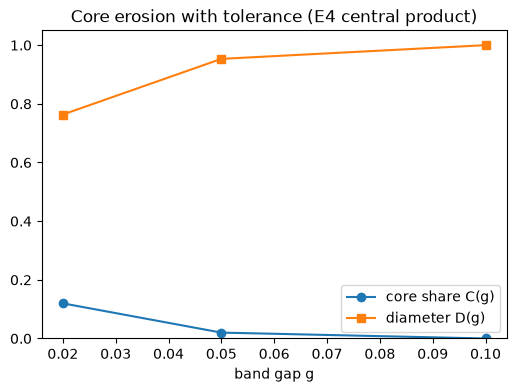

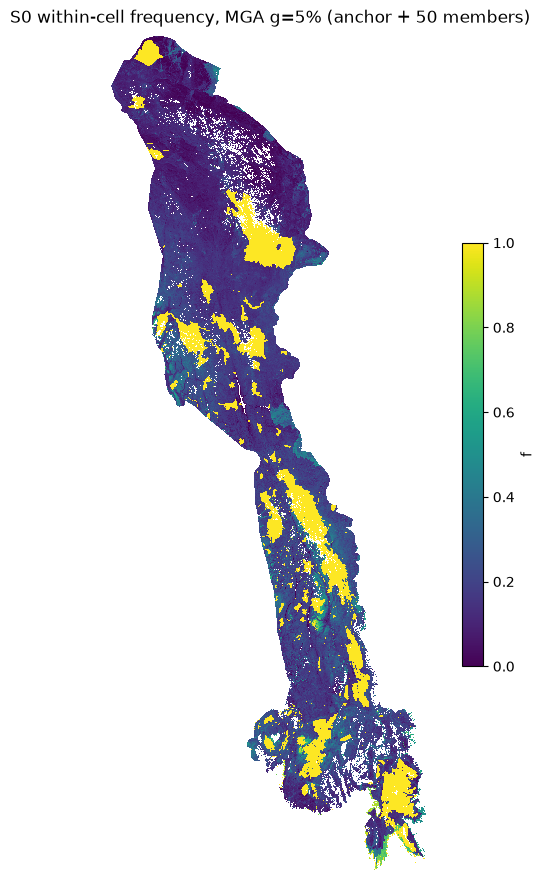

figures -> analyses/y2y/figures/gate2b_*.png


In [4]:
# ---- SS C: figures -- core erosion f(g) + frequency surface at g=5% ------------------------
FIG = ROOT / "analyses" / "y2y" / "figures"
FIG.mkdir(exist_ok=True)
gs = [stats[t]["g"] for t in ("g02", "g05", "g10")]
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(gs, [stats[t]["C"] for t in ("g02", "g05", "g10")], "o-", label="core share C(g)")
ax.plot(gs, [stats[t]["D"] for t in ("g02", "g05", "g10")], "s-", label="diameter D(g)")
ax.set_xlabel("band gap g"); ax.set_ylim(0, 1.05); ax.legend()
ax.set_title("Core erosion with tolerance (E4 central product)")
fig.savefig(FIG / "gate2b_core_erosion.png", dpi=200, bbox_inches="tight")
plt.show()

F = np.full(pu.shape, np.nan, dtype=np.float32)
F[pu] = S["g05"].mean(axis=0)
fig, ax = plt.subplots(figsize=(7, 11))
im = ax.imshow(F, cmap="viridis", vmin=0, vmax=1, interpolation="nearest")
ax.set_title("S0 within-formulation frequency, MGA g=5% (anchor + 50 members)")
ax.axis("off")
fig.colorbar(im, ax=ax, shrink=0.5, label="f")
fig.savefig(FIG / "gate2b_s0_frequency_mga.png", dpi=200, bbox_inches="tight")
plt.show()
print("figures -> analyses/y2y/figures/gate2b_*.png")

In [5]:
# ---- SS D: seed + formulation audit (verdict-rule hash per spec s9) -------------------------------
RULE = ("v2: D=maxHam/(2*m_disc), C=all-selected/m_disc, over anchor+k at g, discretionary; "
        "PLATEAU-RICH iff D>=0.10 and C<=0.90; NEAR-UNIQUE iff D<0.02 or C>0.98; else INTERMEDIATE")
rule_hash = hashlib.sha256(RULE.encode()).hexdigest()[:16]
np.savez_compressed(RUN / "solutions_g05.npz",
                    S=S["g05"].astype(np.uint8), f=S["g05"].mean(axis=0).astype(np.float32),
                    locked=locked[pu], pu_mask=pu)
audit = dict(formulation_id=META["cell_id"], estimator=META["estimator"],
             anchor_objective=META["anchor_objective"], k=50, g_levels=list(GS.values()),
             m_disc=m_disc, stats=stats, verdict=VERDICT,
             verdict_rule=RULE, verdict_rule_hash=f"v2_{rule_hash}",
             created_utc=datetime.now(timezone.utc).isoformat())
(RUN / "formulation_audit.json").write_text(json.dumps(audit, indent=2))
print(f"wrote solutions_g05.npz + formulation_audit.json (verdict_rule_hash v2_{rule_hash})")

wrote solutions_g05.npz + cell_audit.json (verdict_rule_hash v2_8db80fed1c702638)


## Next

Bring to the chat: the §B verdict line with D/C at all three g levels, the core-erosion
figure, and 09's cost summary. The Gate-3-freeze vs Claims-B+C-pivot decision is made there.
Fill results_log R7 in the same session.